<a href="https://colab.research.google.com/github/sachinuke36/agricultural-ai-copilot/blob/main/crop_recommendation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Crop_recommendation.csv to Crop_recommendation.csv


In [ ]:
df = pd.read_csv("Crop_recommendation.csv")
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [ ]:
df.shape

(2200, 8)

In [ ]:
df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [ ]:
df.isnull().sum()

,0
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0
label,0


In [ ]:
df["label"].value_counts()

,count
label,
rice,100
maize,100
chickpea,100
kidneybeans,100
pigeonpeas,100
mothbeans,100
mungbean,100
blackgram,100
lentil,100


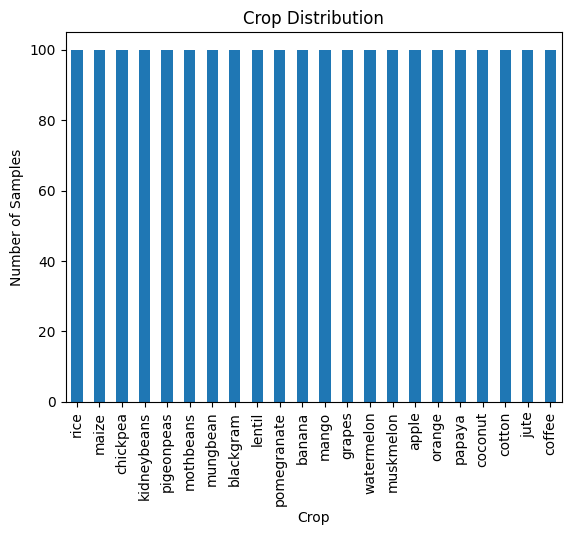

In [ ]:
import matplotlib.pyplot as plt

df["label"].value_counts().plot(kind="bar")

plt.xlabel("Crop")
plt.ylabel("Number of Samples")
plt.title("Crop Distribution")

plt.show()

In [ ]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [ ]:
df.groupby("label")[["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]].mean().round(2)

,N,P,K,temperature,humidity,ph,rainfall
label,,,,,,,
apple,20.80,134.22,199.89,22.63,92.33,5.93,112.65
banana,100.23,82.01,50.05,27.38,80.36,5.98,104.63
blackgram,40.02,67.47,19.24,29.97,65.12,7.13,67.88
chickpea,40.09,67.79,79.92,18.87,16.86,7.34,80.06
coconut,21.98,16.93,30.59,27.41,94.84,5.98,175.69
coffee,101.20,28.74,29.94,25.54,58.87,6.79,158.07
cotton,117.77,46.24,19.56,23.99,79.84,6.91,80.40
grapes,23.18,132.53,200.11,23.85,81.88,6.03,69.61
jute,78.40,46.86,39.99,24.96,79.64,6.73,174.79


<Figure size 1400x600 with 0 Axes>

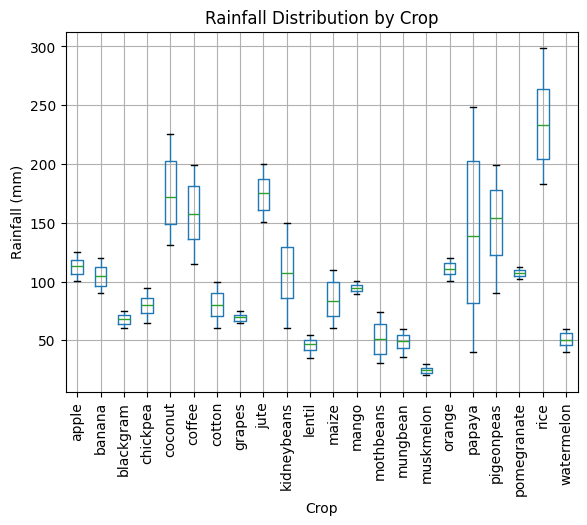

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

df.boxplot(
    column="rainfall",
    by="label",
    rot=90
)

plt.title("Rainfall Distribution by Crop")
plt.suptitle("")
plt.xlabel("Crop")
plt.ylabel("Rainfall (mm)")

plt.show()

<Figure size 1400x600 with 0 Axes>

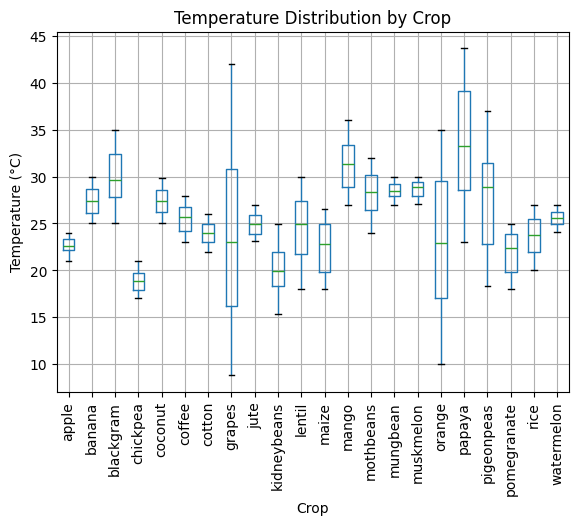

In [ ]:
plt.figure(figsize=(14, 6))

df.boxplot(
    column="temperature",
    by="label",
    rot=90
)

plt.title("Temperature Distribution by Crop")
plt.suptitle("")
plt.xlabel("Crop")
plt.ylabel("Temperature (°C)")

plt.show()

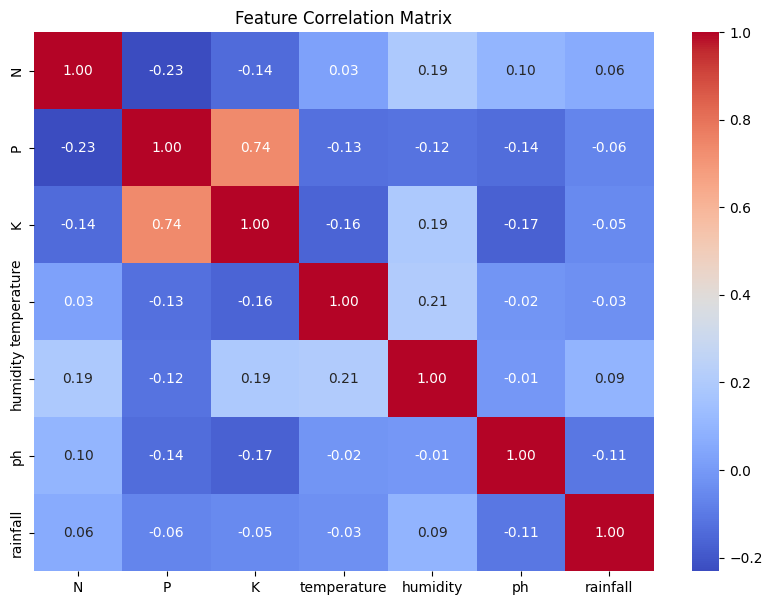

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

sns.heatmap(
    df.drop(columns="label").corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")

plt.show()

In [ ]:
X = df.drop("label", axis=1)
y = df["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2200, 7)
y shape: (2200,)


In [ ]:
print(X.head())

    N   P   K  temperature   humidity        ph    rainfall
0  90  42  43    20.879744  82.002744  6.502985  202.935536
1  85  58  41    21.770462  80.319644  7.038096  226.655537
2  60  55  44    23.004459  82.320763  7.840207  263.964248
3  74  35  40    26.491096  80.158363  6.980401  242.864034
4  78  42  42    20.130175  81.604873  7.628473  262.717340


In [ ]:
print(y.head())

0    rice
1    rice
2    rice
3    rice
4    rice
Name: label, dtype: object


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1760, 7)
X_test : (440, 7)
y_train: (1760,)
y_test : (440,)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print(y_pred[:10])

['orange' 'banana' 'cotton' 'maize' 'orange' 'chickpea' 'rice' 'blackgram'
 'banana' 'orange']


In [ ]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,orange,orange
1,banana,banana
2,cotton,cotton
3,maize,maize
4,orange,orange
5,chickpea,chickpea
6,rice,rice
7,blackgram,blackgram
8,banana,banana
9,orange,orange


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.9954545454545455
Accuracy (%): 99.54545454545455


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
      papaya       1.00    

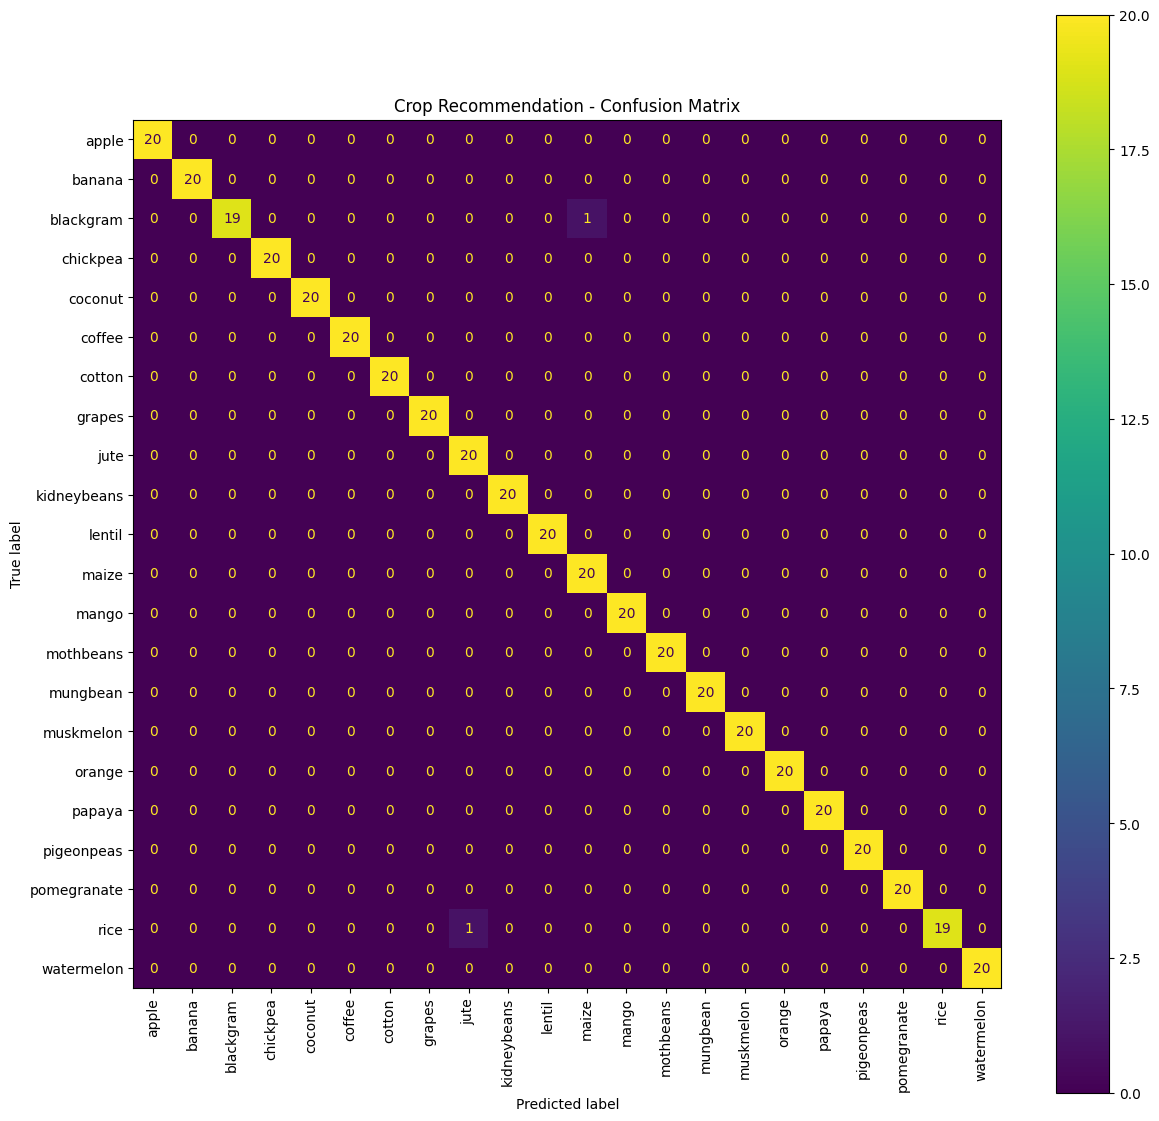

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

fig, ax = plt.subplots(figsize=(14, 14))

disp.plot(
    ax=ax,
    xticks_rotation=90
)

plt.title("Crop Recommendation - Confusion Matrix")
plt.show()

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

       Feature  Importance
6     rainfall    0.219641
4     humidity    0.217058
2            K    0.180813
1            P    0.151342
0            N    0.103356
3  temperature    0.075485
5           ph    0.052305


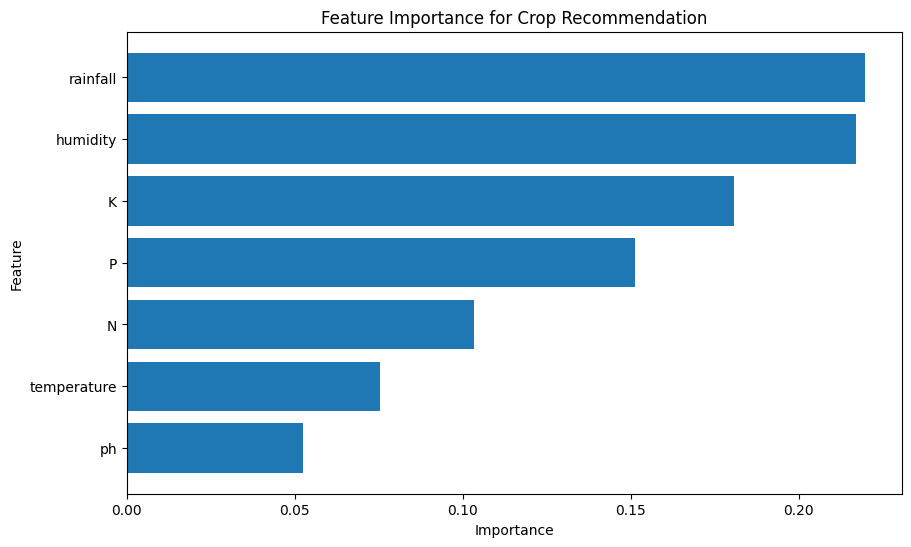

In [ ]:
plt.figure(figsize=(10, 6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance for Crop Recommendation")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
import joblib

joblib.dump(model, "crop_recommendation_model.pkl")

['crop_recommendation_model.pkl']

In [ ]:
features = list(X.columns)

joblib.dump(features, "crop_features.pkl")

['crop_features.pkl']